# Week 1 Task: Data Acquisition, Cleaning, and Preprocessing

## YUVA Internship – Virtual Data Science with Python Trainee

### Objective
The objective of this task is to acquire a publicly available dataset, explore its structure and quality, identify missing values, inconsistencies and outliers, and perform appropriate data cleaning and preprocessing using Python.

### Dataset
**UCI Automobile Dataset**

The dataset contains information about automobiles, including technical specifications, dimensions, engine characteristics, fuel-related attributes and price.

### Tools and Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### Workflow
1. Data acquisition
2. Data loading
3. Initial data exploration
4. Missing value identification
5. Missing value treatment
6. Duplicate and inconsistency checks
7. Outlier detection and treatment
8. Data preprocessing
9. Final validation
10. Before-and-after comparison

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import os
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [31]:
DATA_PATH = "data/imports-85.data"
NAMES_PATH = "data/imports-85.names"

OUTPUT_DIR = "output"
SCREENSHOT_DIR = "screenshots"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

print("Data file:", DATA_PATH)
print("Output folder:", OUTPUT_DIR)

Data file: data/imports-85.data
Output folder: output


## 1. Data Acquisition

The Automobile dataset was obtained from the UCI Machine Learning Repository, a publicly available and widely used source of datasets for machine learning and data analysis.

The dataset is stored locally in the project `data` directory. The `.data` file contains the automobile records, while the `.names` file provides information about the attributes.

The dataset is suitable for this task because it contains numerical and categorical variables along with missing values represented using the `?` symbol.

In [32]:
columns = [
    "symboling",
    "normalized_losses",
    "make",
    "fuel_type",
    "aspiration",
    "num_doors",
    "body_style",
    "drive_wheels",
    "engine_location",
    "wheel_base",
    "length",
    "width",
    "height",
    "curb_weight",
    "engine_type",
    "num_cylinders",
    "engine_size",
    "fuel_system",
    "bore",
    "stroke",
    "compression_ratio",
    "horsepower",
    "peak_rpm",
    "city_mpg",
    "highway_mpg",
    "price"
]

print("Number of columns:", len(columns))

Number of columns: 26


In [33]:
df = pd.read_csv(
    DATA_PATH,
    names=columns,
    na_values="?",
    header=None
)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Rows: 205
Columns: 26


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [34]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (205, 26)

Data Types:
symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders            str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             ------

## 2. Initial Data Exploration

Initial exploration was performed to understand the size, structure, data types and statistical characteristics of the dataset.

The `describe()` function was used to obtain summary statistics for numerical variables. This helps identify unusual values and understand the distribution of important automobile attributes.

In [35]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
normalized_losses,164.0,NaN,NaN,NaN,122.0,35.442168,65.0,94.0,115.0,150.0,256.0
make,205,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_doors,203,2,four,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_style,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive_wheels,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_location,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel_base,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


In [36]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

print("Columns containing missing values:")
missing_summary

Columns containing missing values:


,Missing Values,Missing Percentage
normalized_losses,41,20.00
bore,4,1.95
stroke,4,1.95
price,4,1.95
num_doors,2,0.98
horsepower,2,0.98
peak_rpm,2,0.98


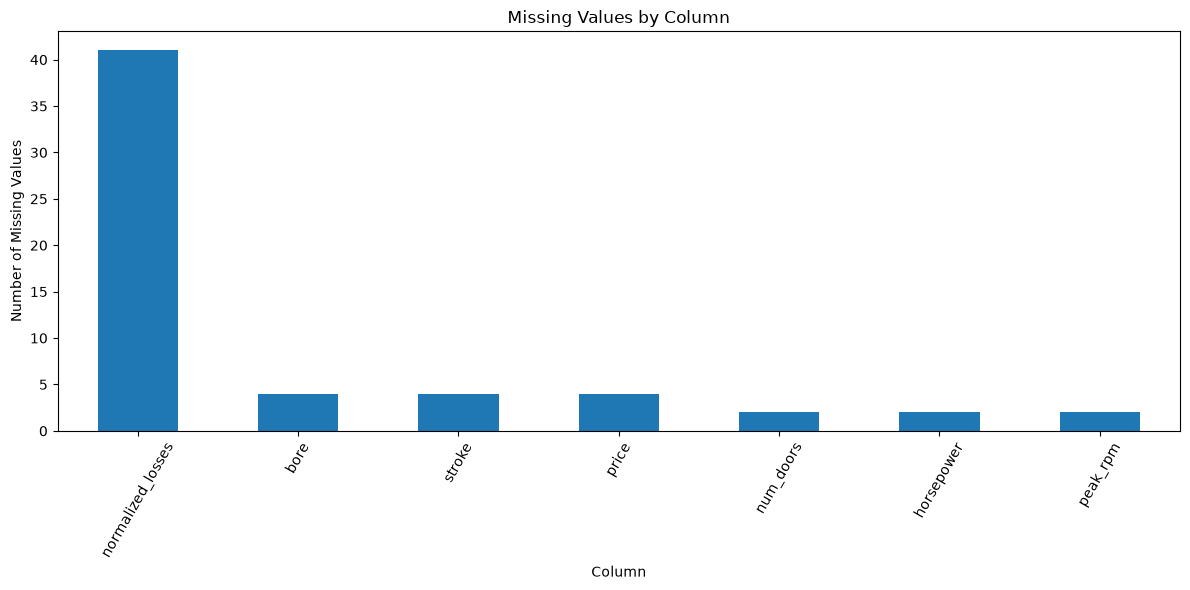

In [37]:
plt.figure(figsize=(12, 6))

missing_plot = missing_summary["Missing Values"]

missing_plot.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=60)
plt.tight_layout()

plt.savefig(
    os.path.join(SCREENSHOT_DIR, "04_missing_values_chart.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 3. Handling Missing Values

Missing values were identified using Pandas and were originally represented by the `?` symbol in the raw dataset.

For numerical variables, missing values are replaced using the **median** of the respective column. Median imputation was selected because it is less sensitive to extreme values than mean imputation.

For categorical variables, missing values are replaced using the **mode**, which represents the most frequently occurring category.

This approach preserves the available records while avoiding unnecessary deletion of rows.

In [38]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

# Fill numerical missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing value treatment completed.")

Missing value treatment completed.


In [39]:
remaining_missing = df.isnull().sum()

print("Total remaining missing values:", remaining_missing.sum())

if remaining_missing.sum() == 0:
    print("No missing values remain in the dataset.")
else:
    print(remaining_missing[remaining_missing > 0])

Total remaining missing values: 0
No missing values remain in the dataset.


## 4. Duplicate and Consistency Checks

Duplicate records can introduce bias into statistical analysis and machine learning models. Therefore, duplicate rows were checked and removed if present.

The dataset was also examined for inconsistent categorical values and invalid numerical values.

In [40]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Duplicate rows found: 0
No duplicate rows found.


In [41]:
categorical_columns = [
    "make",
    "fuel_type",
    "aspiration",
    "num_doors",
    "body_style",
    "drive_wheels",
    "engine_location",
    "engine_type",
    "num_cylinders",
    "fuel_system"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


make:
<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str

fuel_type:
<StringArray>
['gas', 'diesel']
Length: 2, dtype: str

aspiration:
<StringArray>
['std', 'turbo']
Length: 2, dtype: str

num_doors:
<StringArray>
['two', 'four']
Length: 2, dtype: str

body_style:
<StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
Length: 5, dtype: str

drive_wheels:
<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

engine_location:
<StringArray>
['front', 'rear']
Length: 2, dtype: str

engine_type:
<StringArray>
['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv']
Length: 7, dtype: str

num_cylinders:
<String

## 5. Identifying Erroneous Numerical Entries

Numerical variables were checked for impossible or clearly invalid values.

For automobile specifications, variables such as price, engine size, horsepower, wheel base, length, width, height and fuel economy should contain positive values.

Invalid values were identified before performing outlier analysis.

In [42]:
positive_columns = [
    "wheel_base",
    "length",
    "width",
    "height",
    "curb_weight",
    "engine_size",
    "bore",
    "stroke",
    "compression_ratio",
    "horsepower",
    "peak_rpm",
    "city_mpg",
    "highway_mpg",
    "price"
]

for col in positive_columns:
    invalid_count = (df[col] <= 0).sum()
    print(f"{col}: {invalid_count} non-positive values")

wheel_base: 0 non-positive values
length: 0 non-positive values
width: 0 non-positive values
height: 0 non-positive values
curb_weight: 0 non-positive values
engine_size: 0 non-positive values
bore: 0 non-positive values
stroke: 0 non-positive values
compression_ratio: 0 non-positive values
horsepower: 0 non-positive values
peak_rpm: 0 non-positive values
city_mpg: 0 non-positive values
highway_mpg: 0 non-positive values
price: 0 non-positive values


## 6. Outlier Detection

Outliers are observations that differ substantially from the majority of the data.

The Interquartile Range (IQR) method was used to identify potential outliers in numerical variables.

The IQR is calculated as:

**IQR = Q3 - Q1**

Values below:

**Q1 - 1.5 × IQR**

or above:

**Q3 + 1.5 × IQR**

are considered potential outliers.

Because extreme automobile values can sometimes represent genuine vehicles rather than errors, outliers were not automatically deleted. Instead, the analysis uses a controlled capping approach for selected numerical features.

In [43]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    "Outlier Count",
    ascending=False
)

,Column,Lower Bound,Upper Bound,Outlier Count
10,compression_ratio,7.400,10.600,28
9,stroke,2.660,3.860,20
15,price,-5280.000,29568.000,14
7,engine_size,31.000,207.000,10
4,width,59.900,71.100,8
1,normalized_losses,47.000,191.000,8
11,horsepower,1.000,185.000,6
2,wheel_base,82.650,114.250,3
14,highway_mpg,11.500,47.500,3
13,city_mpg,2.500,46.500,2


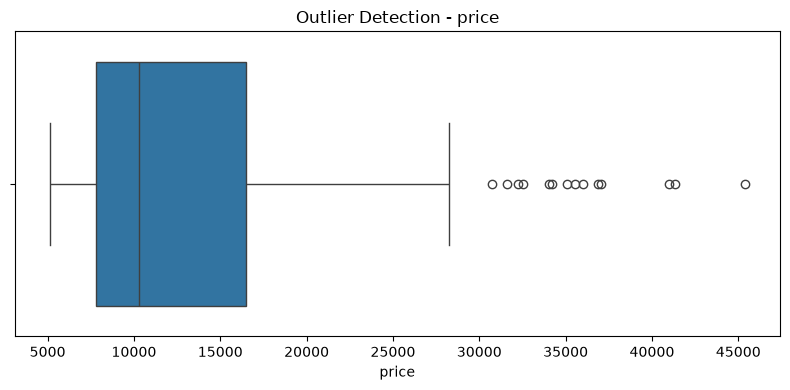

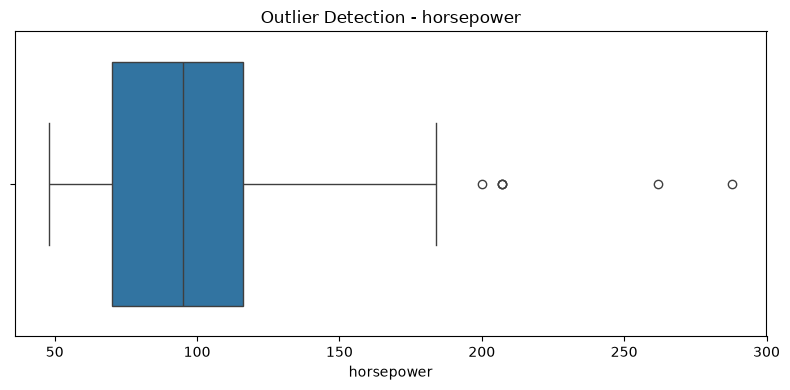

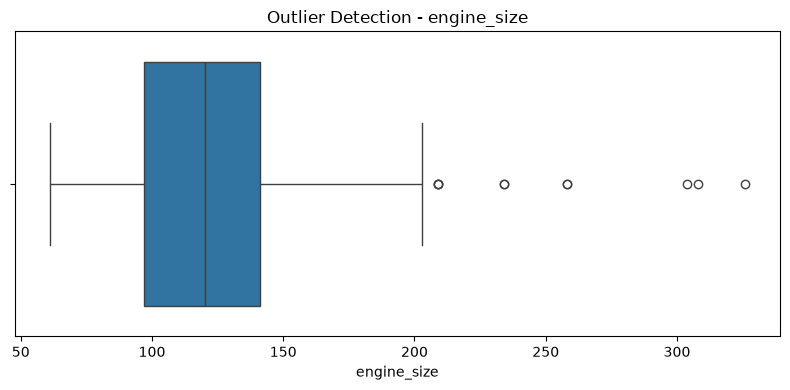

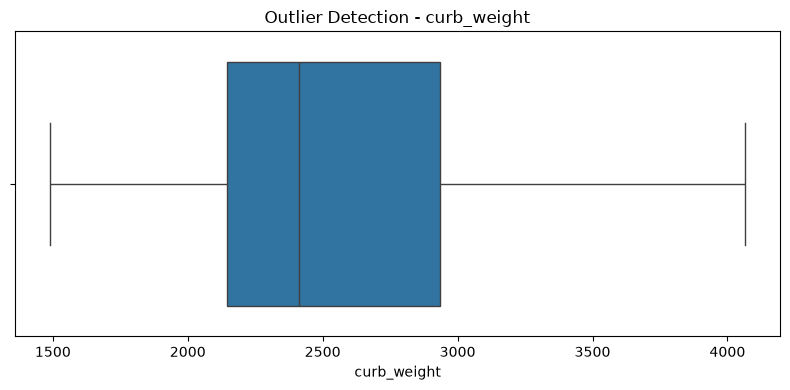

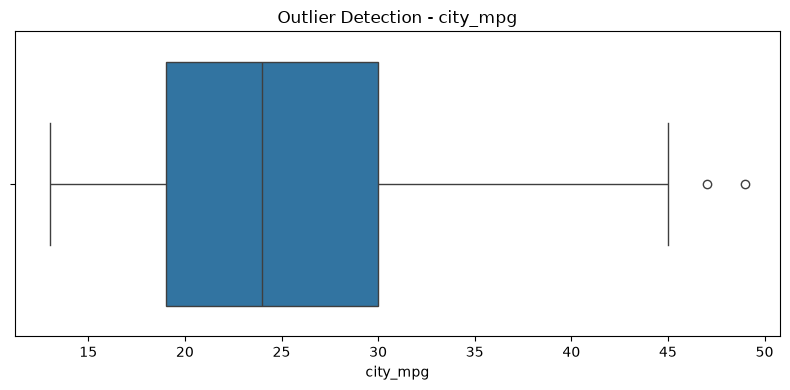

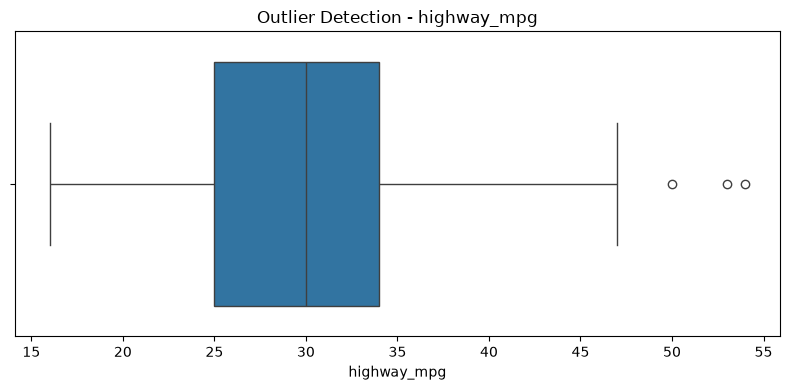

In [44]:
selected_outlier_columns = [
    "price",
    "horsepower",
    "engine_size",
    "curb_weight",
    "city_mpg",
    "highway_mpg"
]

for col in selected_outlier_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            SCREENSHOT_DIR,
            f"outlier_before_{col}.png"
        ),
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 7. Outlier Treatment

Extreme observations were handled using IQR-based capping (winsorization).

Instead of deleting potentially useful automobile records, values outside the IQR boundaries were replaced with the corresponding lower or upper boundary.

This approach reduces the influence of extreme observations while preserving the number of records in the dataset.

In [45]:
df_clean = df.copy()

outlier_columns = [
    "price",
    "horsepower",
    "engine_size",
    "curb_weight",
    "city_mpg",
    "highway_mpg"
]

for col in outlier_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier capping completed.")

Outlier capping completed.


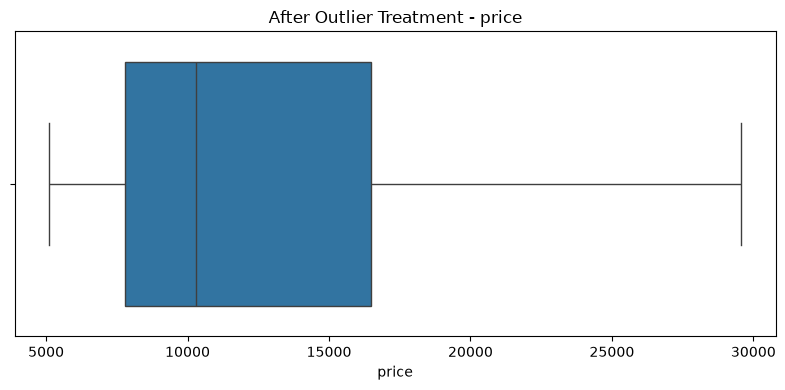

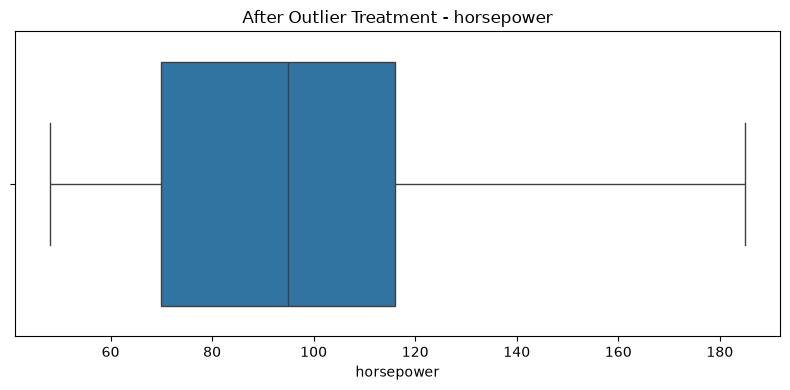

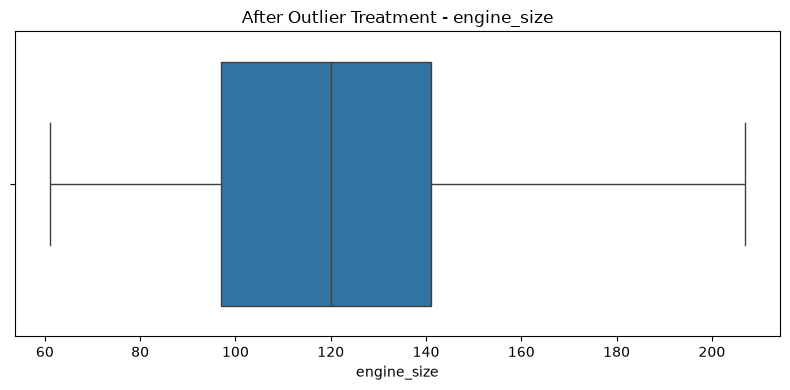

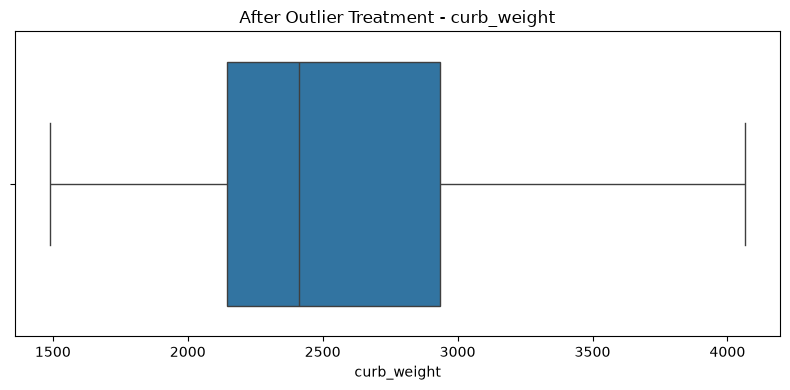

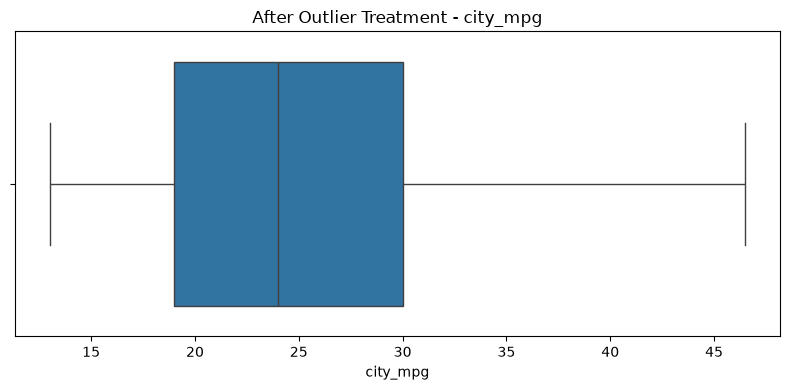

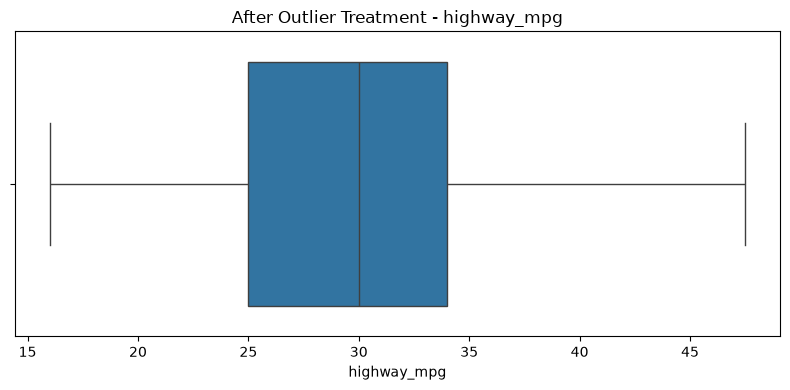

In [46]:
for col in outlier_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"After Outlier Treatment - {col}")
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            SCREENSHOT_DIR,
            f"outlier_after_{col}.png"
        ),
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 8. Data Preprocessing

After cleaning the dataset, categorical variables were converted into numerical form so that they can be used in statistical and machine learning workflows.

One-hot encoding was selected for categorical variables because it avoids imposing an artificial numerical order between categories.

Numerical features were standardized using StandardScaler. Standardization transforms the numerical variables so that they have approximately zero mean and unit variance.

The original cleaned dataset is retained separately so that the transformations do not destroy the interpretable automobile values.

In [47]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_columns,
    drop_first=True
)

print("Encoding completed.")
print("Original cleaned shape:", df_clean.shape)
print("Encoded shape:", df_encoded.shape)

Encoding completed.
Original cleaned shape: (205, 26)
Encoded shape: (205, 66)


In [48]:
numeric_encoded_columns = df_encoded.select_dtypes(
    include=np.number
).columns

scaler = StandardScaler()

df_encoded[numeric_encoded_columns] = scaler.fit_transform(
    df_encoded[numeric_encoded_columns]
)

print("Numerical feature scaling completed.")

Numerical feature scaling completed.


## 9. Final Dataset Validation

The final dataset was checked to ensure that:

- Missing values were addressed.
- Duplicate records were removed if present.
- Numerical features were cleaned.
- Selected outliers were treated.
- Categorical features were encoded.
- Numerical features were standardized.
- The resulting dataset is ready for further analysis or machine learning.

In [49]:
print("FINAL DATASET VALIDATION")
print("=" * 50)

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Encoded rows:", len(df_encoded))

print("\nMissing values in cleaned dataset:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows in cleaned dataset:")
print(df_clean.duplicated().sum())

print("\nEncoded dataset shape:")
print(df_encoded.shape)

print("\nValidation completed.")

FINAL DATASET VALIDATION
Original rows: 205
Cleaned rows: 205
Encoded rows: 205

Missing values in cleaned dataset:
0

Duplicate rows in cleaned dataset:
1

Encoded dataset shape:
(205, 66)

Validation completed.


## 10. Before and After Preprocessing Comparison

A comparison between the original and cleaned datasets was performed to understand the effect of the preprocessing process.

The comparison focuses on:

- Number of records
- Number of variables
- Missing values
- Duplicate records
- Data representation

In [50]:
comparison = pd.DataFrame({
    "Measure": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Original Dataset": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "Cleaned Dataset": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

comparison

,Measure,Original Dataset,Cleaned Dataset
0,Number of Rows,205,205
1,Number of Columns,26,26
2,Missing Values,0,0
3,Duplicate Rows,0,1


## 11. Saving the Processed Dataset

The cleaned automobile dataset is saved as a CSV file for future analysis.

Two versions are retained:

1. `cleaned_automobile.csv` – cleaned dataset with interpretable categorical values.
2. `preprocessed_automobile.csv` – encoded and standardized dataset suitable for machine learning workflows.

In [51]:
cleaned_path = os.path.join(
    OUTPUT_DIR,
    "cleaned_automobile.csv"
)

preprocessed_path = os.path.join(
    OUTPUT_DIR,
    "preprocessed_automobile.csv"
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "preprocessing_summary.csv"
)

df_clean.to_csv(cleaned_path, index=False)
df_encoded.to_csv(preprocessed_path, index=False)
comparison.to_csv(summary_path, index=False)

print("Files saved successfully:")
print(cleaned_path)
print(preprocessed_path)
print(summary_path)

Files saved successfully:
output\cleaned_automobile.csv
output\preprocessed_automobile.csv
output\preprocessing_summary.csv


## 12. Challenges Faced and Solutions

### Challenge 1: Missing Values
The original dataset contained missing values represented by the `?` symbol.

**Solution:**  
The `?` values were converted to missing values using Pandas and numerical variables were imputed using their median values, while categorical variables were filled using their mode.

### Challenge 2: Mixed Data Types
The dataset contained both numerical and categorical variables.

**Solution:**  
Numerical and categorical variables were identified separately. Categorical variables were subsequently transformed using one-hot encoding.

### Challenge 3: Extreme Values
Several numerical variables contained potential outliers.

**Solution:**  
The IQR method was used to identify potential outliers. Selected numerical variables were treated using IQR-based capping rather than deleting records.

### Challenge 4: Preparing Data for Further Analysis
Machine learning algorithms generally require numerical input and may be affected by different feature scales.

**Solution:**  
Categorical variables were one-hot encoded and numerical variables were standardized using StandardScaler.

---

## 13. Impact of Preprocessing

Data preprocessing can significantly influence subsequent analysis.

Removing duplicate records prevents repeated observations from influencing statistical results. Treating missing values provides a more complete dataset and avoids errors during analysis.

Outlier treatment reduces the influence of extreme observations while retaining the majority of the available data. Encoding categorical variables makes the data compatible with machine learning algorithms.

Standardization ensures that numerical features with different units and ranges can be compared more appropriately by algorithms that are sensitive to feature scale.

However, preprocessing decisions can also affect the results. For example, replacing missing values with median or mode values introduces estimated values, while outlier capping changes extreme observations. Therefore, preprocessing methods should always be selected based on the characteristics and intended use of the dataset.

---

## 14. Conclusion

The UCI Automobile dataset was successfully acquired, explored, cleaned and preprocessed using Python.

The process included dataset inspection, missing-value treatment, duplicate checking, consistency validation, outlier detection, outlier treatment, categorical encoding and numerical feature scaling.

The resulting cleaned dataset provides a more consistent foundation for further exploratory data analysis, visualization and machine learning applications.